In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm # For a nice progress bar

# Setup device agnostic code (Will use GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


The **MNIST database** (Modified National Institute of Standards and Technology database) is a large dataset of 70,000 grayscale images of handwritten digits (0–9), widely used as a benchmark for training and testing image processing systems and machine learning algorithms.  It consists of 60,000 training images and 10,000 testing images, with each image standardized to a 28×28 pixel size and normalized to fit within a fixed bounding box.

* 70,000 grayscale images
* (0 - 9) handwritten digits
* 60,000 training
* 10,000 testing
* each image = 28×28 pixels
* flattened → 784 features

In [28]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

transform = transforms.ToTensor()

# 1. Download the FULL training dataset (60,000 images)
full_train_data = datasets.MNIST(
    root="data",
    train=True, download=True, transform=transform
)

# 2. Download the locked TEST dataset (10,000 images)
test_data = datasets.MNIST(
    root="data", train=False, download=True, transform=transform
)

# 3. Split the full training data into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_train_data)) # 48,000 images
val_size = len(full_train_data) - train_size # 12,000 images

# Use manual seed so the split is exactly the same every time we run it
train_data, val_data = random_split(
    full_train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Create the three DataLoaders
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Testing batches (LOCKED): {len(test_dataloader)}")

Training batches: 1500
Validation batches: 375
Testing batches (LOCKED): 313


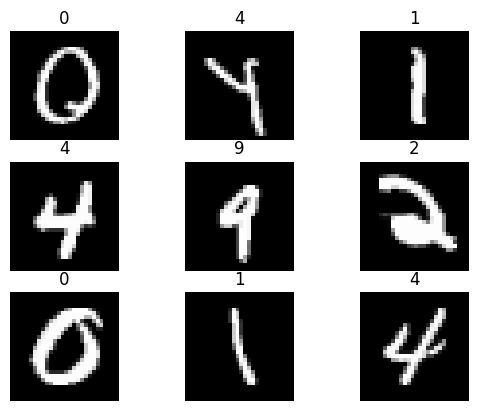

In [29]:
images, labels = next(iter(train_dataloader))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i][0], cmap="gray")  # no squeeze
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()

Image tensor shape: torch.Size([32, 1, 28, 28])
Label tensor shape: torch.Size([32])


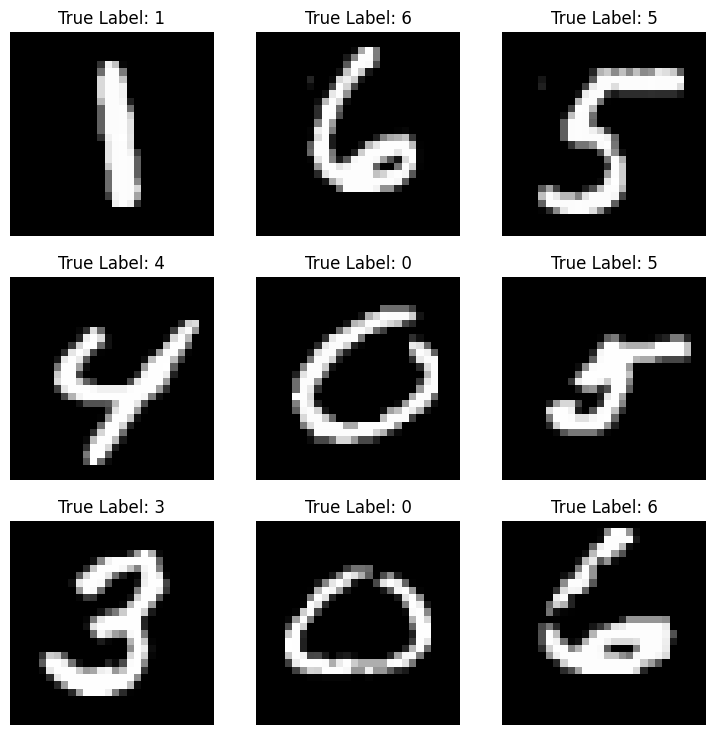

In [30]:
import matplotlib.pyplot as plt

# Grab one single batch of training data
images, labels = next(iter(train_dataloader)) # iter() is like a pointer

print(f"Image tensor shape: {images.shape}") # Should be [32, 1, 28, 28]
print(f"Label tensor shape: {labels.shape}") # Should be [32]

# Plot the first 9 images in the batch
fig = plt.figure(figsize=(9, 9))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
    # .squeeze() removes the color channel dimension so matplotlib can plot the 28x28 grid
    image = images[i-1].squeeze() # (1, 28, 28) → (28, 28)
    label = labels[i-1].item()

    fig.add_subplot(rows, cols, i)
    plt.imshow(image, cmap="gray")
    plt.title(f"True Label: {label}")
    plt.axis(False)

plt.show()

In [31]:
class MNISTVisionModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

# Instantiate the model and send it to the target device
torch.manual_seed(42)
model_0 = MNISTVisionModel(input_shape=1, hidden_units=10, output_shape=10).to(device)
print(model_0)

MNISTVisionModel(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


In [32]:
# Create the accuracy function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [33]:
from tqdm.auto import tqdm

torch.manual_seed(42)
epochs = 3

# Dictionary to track our training history
results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in tqdm(range(epochs)):
    print(f"\nEpoch: {epoch}\n-------")

    ### 1. Training Phase
    train_loss, train_acc = 0, 0
    model_0.train()

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ### 2. Validation Phase (The Practice Exam)
    val_loss, val_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)

            val_pred = model_0(X)
            val_loss += loss_fn(val_pred, y).item()
            val_acc += accuracy_fn(y_true=y, y_pred=val_pred.argmax(dim=1))

        val_loss /= len(val_dataloader)
        val_acc /= len(val_dataloader)

    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f}%")

    # Save results to our dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["val_loss"].append(val_loss)
    results["val_acc"].append(val_acc)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
-------
Train loss: 0.2930 | Train acc: 90.32% | Val loss: 0.1323 | Val acc: 96.03%

Epoch: 1
-------
Train loss: 0.0736 | Train acc: 97.67% | Val loss: 0.0634 | Val acc: 98.02%

Epoch: 2
-------
Train loss: 0.0564 | Train acc: 98.26% | Val loss: 0.0656 | Val acc: 98.12%


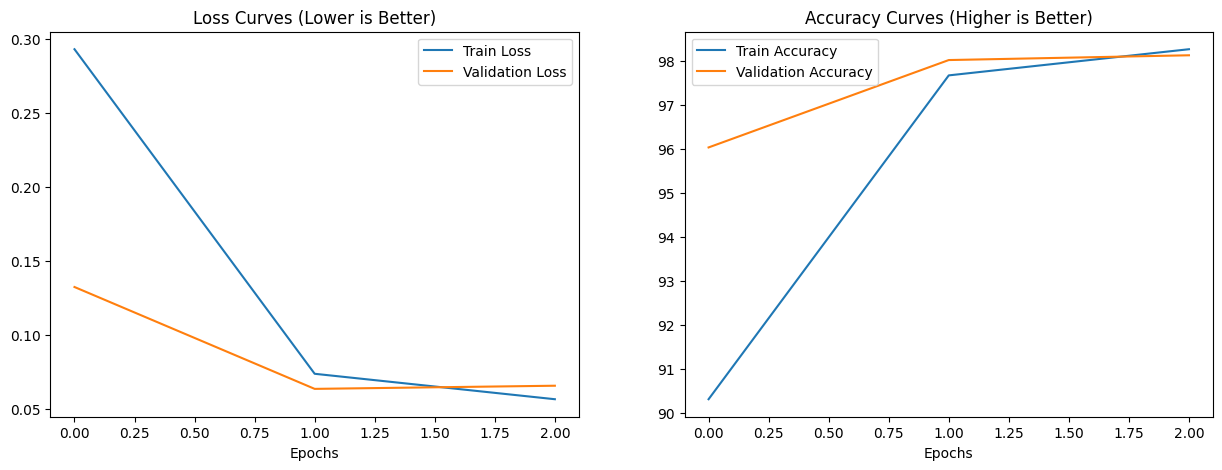

In [34]:
import matplotlib.pyplot as plt

def plot_loss_curves(results):
    loss = results['train_loss']
    val_loss = results['val_loss']
    accuracy = results['train_acc']
    val_accuracy = results['val_acc']
    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss Curves (Lower is Better)')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='Train Accuracy')
    plt.plot(epochs, val_accuracy, label='Validation Accuracy')
    plt.title('Accuracy Curves (Higher is Better)')
    plt.xlabel('Epochs')
    plt.legend()

plot_loss_curves(results)

In [35]:
# Make predictions on the locked Test Set
y_preds = []
y_true = []

model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Running Final Test Set"):
    X, y = X.to(device), y.to(device)

    y_logit = model_0(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

    # Send predictions back to CPU for evaluation libraries
    y_preds.append(y_pred.cpu())
    y_true.append(y.cpu())

# Concatenate all batches into a single tensor
y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)

Running Final Test Set:   0%|          | 0/313 [00:00<?, ?it/s]

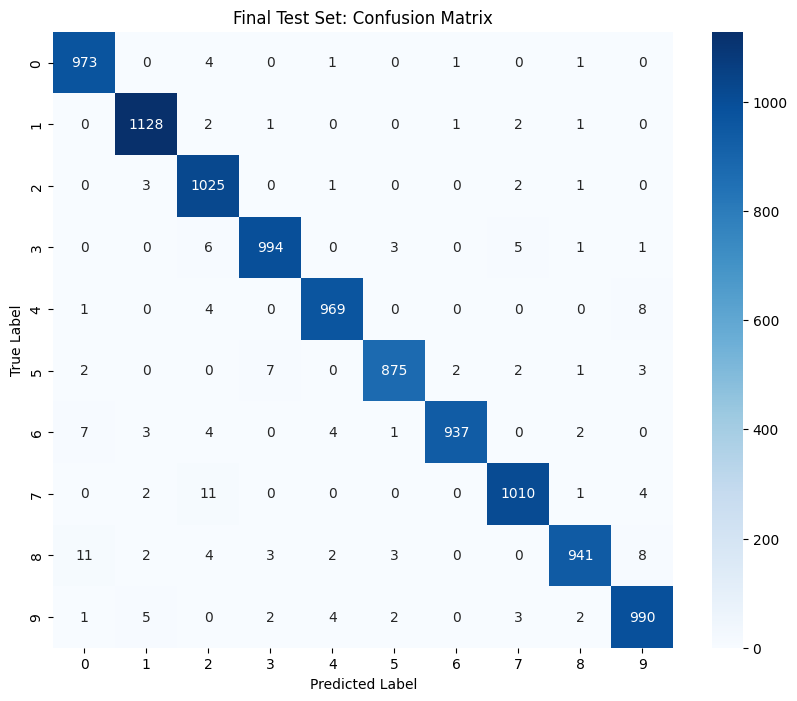


--- Final Test Set: Classification Report ---
              precision    recall  f1-score   support

           0     0.9779    0.9929    0.9853       980
           1     0.9869    0.9938    0.9903      1135
           2     0.9670    0.9932    0.9799      1032
           3     0.9871    0.9842    0.9856      1010
           4     0.9878    0.9868    0.9873       982
           5     0.9898    0.9809    0.9854       892
           6     0.9957    0.9781    0.9868       958
           7     0.9863    0.9825    0.9844      1028
           8     0.9895    0.9661    0.9777       974
           9     0.9763    0.9812    0.9787      1009

    accuracy                         0.9842     10000
   macro avg     0.9844    0.9840    0.9841     10000
weighted avg     0.9843    0.9842    0.9842     10000



In [36]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate the Confusion Matrix
conf_matrix = confusion_matrix(y_true_tensor.numpy(), y_pred_tensor.numpy())

# 2. Plot it using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Test Set: Confusion Matrix')
plt.show()

# 3. Print the Classification Report
print("\n--- Final Test Set: Classification Report ---")
print(classification_report(y_true_tensor.numpy(), y_pred_tensor.numpy(), digits=4))

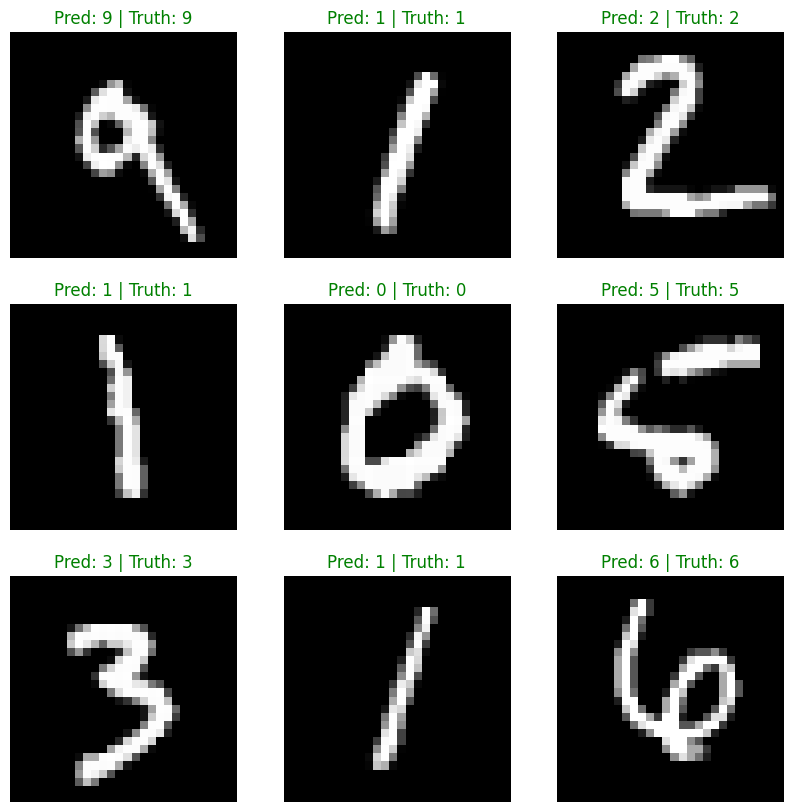

In [37]:
import random

# Get a random batch of test data
test_images, test_labels = next(iter(test_dataloader))

# Pick 9 random images from that batch
random_indices = random.sample(range(len(test_images)), 9)

fig = plt.figure(figsize=(10, 10))
rows, cols = 3, 3

model_0.eval()
with torch.inference_mode():
    for i, idx in enumerate(random_indices):
        # 1. Get the image and label, send image to GPU
        img = test_images[idx]
        label = test_labels[idx]
        img_gpu = img.unsqueeze(0).to(device) # Add batch dimension

        # 2. Make a prediction
        pred_logits = model_0(img_gpu)
        pred_label = pred_logits.argmax(dim=1).item()

        # 3. Plotting
        fig.add_subplot(rows, cols, i+1)
        plt.imshow(img.squeeze(), cmap="gray")

        # Color the title green if correct, red if wrong
        title_color = "green" if pred_label == label else "red"
        plt.title(f"Pred: {pred_label} | Truth: {label}", color=title_color)
        plt.axis(False)

plt.show()

In [21]:
from pathlib import Path
from google.colab import files

# Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save path
MODEL_NAME = "edge_digit_vision_final.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict (the highly optimized weights)
print(f"Saving model artifact to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

# Automatically trigger download to your laptop
files.download(MODEL_SAVE_PATH)

Model saved to edge_digit_vision_v2.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>